In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import torch
import os 
import cv2
import numpy as np
import matplotlib.pyplot as plt

from dataset import PineappleCountDataset
from VAE import VAE
from utils import plot_samples, load_models

In [2]:
import warnings
import matplotlib.cbook

warnings.filterwarnings("ignore")

In [3]:
device = "cuda"

In [4]:
checkpoints_by_stage = {
    'last': {
        'kl_0_00': '/home/rtxmsi1/Downloads/VAE_training-master (2)/checkpoints/betaKL@0.00/weights_ck_398.pt',
        'kl_1_00': '/home/rtxmsi1/Downloads/VAE_training-master (2)/checkpoints/betaKL@1.00/weights_ck_398.pt',
        'kl_2_00': '/home/rtxmsi1/Downloads/VAE_training-master (2)/checkpoints/betaKL@2.00/weights_ck_399.pt',
        'kl_3_00': '/home/rtxmsi1/Downloads/VAE_training-master (2)/checkpoints/betaKL@3.00/weights_ck_398.pt',
        #'kl_4_00': '/home/rtxmsi1/Downloads/VAE_training-master (2)/checkpoints/betaKL@1.00/weights_ck_398.pt',
    },
    'mid': {
        'kl_0_00': '/home/rtxmsi1/Downloads/VAE_training-master (2)/checkpoints/betaKL@0.00/weights_ck_200.pt',
        'kl_1_00': '/home/rtxmsi1/Downloads/VAE_training-master (2)/checkpoints/betaKL@1.00/weights_ck_200.pt',
        'kl_2_00': '/home/rtxmsi1/Downloads/VAE_training-master (2)/checkpoints/betaKL@2.00/weights_ck_200.pt',
        'kl_3_00': '/home/rtxmsi1/Downloads/VAE_training-master (2)/checkpoints/betaKL@3.00/weights_ck_200.pt',
        #'kl_1_00': '/home/rtxmsi1/Downloads/VAE_training-master (2)/checkpoints/betaKL@1.00/weights_ck_200.pt',
    },
    'init': {
        'kl_0_00': '/home/rtxmsi1/Downloads/VAE_training-master (2)/checkpoints/betaKL@0.00/weights_ck_0.pt',
        'kl_1_00': '/home/rtxmsi1/Downloads/VAE_training-master (2)/checkpoints/betaKL@1.00/weights_ck_0.pt',
        'kl_2_00': '/home/rtxmsi1/Downloads/VAE_training-master (2)/checkpoints/betaKL@2.00/weights_ck_0.pt',
        'kl_3_00': '/home/rtxmsi1/Downloads/VAE_training-master (2)/checkpoints/betaKL@3.00/weights_ck_0.pt',
        #'kl_1_00': '/home/rtxmsi1/Downloads/VAE_training-master (2)/checkpoints/betaKL@1.00/weights_ck_0.pt',
    }
}

models = load_models(VAE=VAE, device=device, checkpoints_by_stage=checkpoints_by_stage)

In [5]:
dataset_path = "/home/rtxmsi1/Downloads/VAE_training-master (2)/VERTICAL_IMAGES_FG_BG_FULL_LABELS"
csv_path = "/home/rtxmsi1/Downloads/VAE_training-master (2)/DATASET.csv"

In [6]:
df = pd.read_csv(csv_path)
dataset_pineapple = PineappleCountDataset(train=True, train_ratio=0.1, 
                                          root_dir=dataset_path,
                                          resize_shape=(256, 256),
                                          dataframe=df)

In [7]:
filtered_test_dataset = [sample for sample in dataset_pineapple if sample['label'] == 2]

In [8]:
label_names = dataset_pineapple.label_to_text
label_names

{0: 'backgrounds', 1: 'foregrounds', 2: 'full_labels'}

In [8]:
from utils import visualize_reconstructions_dict, extract_latents, plot_latents_all_models, plot_latents_all_models_3d_plotly, plot_latents_all_models_3d, extract_latents

In [10]:
model = models['last']['kl_3_00']

In [9]:
def extract_latents_without_flatten(model, test_loader, target_key='label', device='cuda'):
    model.eval()
    model.to(device)

    all_latents = []
    all_targets = []

    with torch.no_grad():
        for batch in test_loader:
            input_tensor = batch['image'].to(device).unsqueeze(0)

            batch_size, _, height, width = input_tensor.shape
            noise = torch.randn((batch_size, 4, height // 8, width // 8), device=device)
            latent, mean, logvar = model.encoder(input_tensor, noise)

            all_latents.append(latent.squeeze(0).cpu().numpy())
            all_targets.append(batch[target_key])

    all_latents = np.stack(all_latents)
    targets_cleaned = np.array(all_targets)

    return all_latents, targets_cleaned

In [23]:
data_cleaned, label_cleaned = extract_latents_without_flatten(model, filtered_test_dataset, target_key="label", device=device)

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def extract_latents_without_flatten(model, test_loader, target_key='label', device='cuda'):
    model.eval()
    model.to(device)

    all_latents = []
    all_targets = []

    with torch.no_grad():
        for batch in test_loader:
            input_tensor = batch['image'].to(device).unsqueeze(0)

            batch_size, _, height, width = input_tensor.shape
            noise = torch.randn((batch_size, 4, height // 8, width // 8), device=device)
            latent, mean, logvar = model.encoder(input_tensor, noise)

            all_latents.append(latent.squeeze(0).cpu().numpy())
            all_targets.append(batch[target_key])

    all_latents = np.stack(all_latents)
    targets_cleaned = np.array(all_targets)

    return all_latents, targets_cleaned

def get_representative_latents(data_latents: np.ndarray, k=5):
    data_tensor = torch.from_numpy(data_latents)
    mean_latent = data_tensor.mean(dim=0)  # (C, H, W)

    flattened = data_tensor.view(data_tensor.size(0), -1)  # (N, C*H*W)
    mean_flattened = mean_latent.view(-1)  # (C*H*W)

    distances = torch.norm(flattened - mean_flattened, dim=1)  # (N,)
    _, indices = torch.topk(distances, k=k, largest=False)

    representative_latents = data_tensor[indices]  # (k, C, H, W)

    return representative_latents, mean_latent, indices

def decode_latents(model, latents, device='cpu'):
    model.eval()
    model.decoder.to(device)
    latents = latents.to(device)
    with torch.no_grad():
        reconstructions = model.decoder(latents).cpu().squeeze()
    # Remove channel dim if it equals 1
    if reconstructions.ndim == 4 and reconstructions.shape[1] == 1:
        reconstructions = reconstructions[:, 0, :, :]
    return reconstructions

def plot_reconstructions_grid(all_reconstructions, model_names):
    """
    all_reconstructions: list of torch.Tensor, each of shape (k+1, H, W) decoded for each model
    model_names: list of model keys (e.g. ['kl_0_00', 'kl_1_00', ...])
    
    Plots all models in rows; each row shows k representative + mean latent images.
    """
    num_models = len(all_reconstructions)
    k_plus_1 = all_reconstructions[0].size(0)  # e.g. 6 = 5 reps + mean

    plt.figure(figsize=(3 * k_plus_1, 3 * num_models))

    for row_idx, reconstructions in enumerate(all_reconstructions):
        titles = [f"Rep {i+1}" for i in range(k_plus_1 - 1)] + ["Mean"]
        for col_idx in range(k_plus_1):
            plt.subplot(num_models, k_plus_1, row_idx * k_plus_1 + col_idx + 1)

            img = reconstructions[col_idx]
            if img.ndim == 3 and img.shape[0] in [1, 3]:  # channel-first
                img = img.permute(1, 2, 0).numpy()

            cmap = 'gray' if img.ndim == 2 or (img.ndim == 3 and img.shape[-1] == 1) else None
            plt.imshow(img.squeeze(), cmap=cmap)
            if col_idx == 0:
                plt.ylabel(model_names[row_idx], fontsize=12)
            plt.title(titles[col_idx])
            plt.axis('off')

    plt.tight_layout()
    plt.show()

# --- Driver code ---

def analyze_and_plot_all_models(models, test_loader, target_key='label', device='cuda', k=5):
    all_reconstructions = []
    model_names = []

    for model_name, model in models.items():
        print(f"Processing model: {model_name}")

        # 1. Extract latents
        data_latents, targets = extract_latents_without_flatten(model, test_loader, target_key, device)

        # 2. Get representative latents + mean latent
        reps, mean_latent, indices = get_representative_latents(data_latents, k)

        # 3. Decode all latents (representatives + mean)
        latents_to_decode = torch.cat([reps, mean_latent.unsqueeze(0)], dim=0)
        reconstructions = decode_latents(model, latents_to_decode, device='cpu')

        all_reconstructions.append(reconstructions)
        model_names.append(model_name)

    # 4. Plot all in a grid: each model is a row, each column is rep or mean
    plot_reconstructions_grid(all_reconstructions, model_names)


Processing model: kl_0_00
Processing model: kl_1_00
Processing model: kl_2_00
Processing model: kl_3_00


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.031524032..0.921955].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.036034785..1.0122194].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0632937..1.014486].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.027384115..1.0369903].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.08973832..0.9388988].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.044938095..0.7933887].


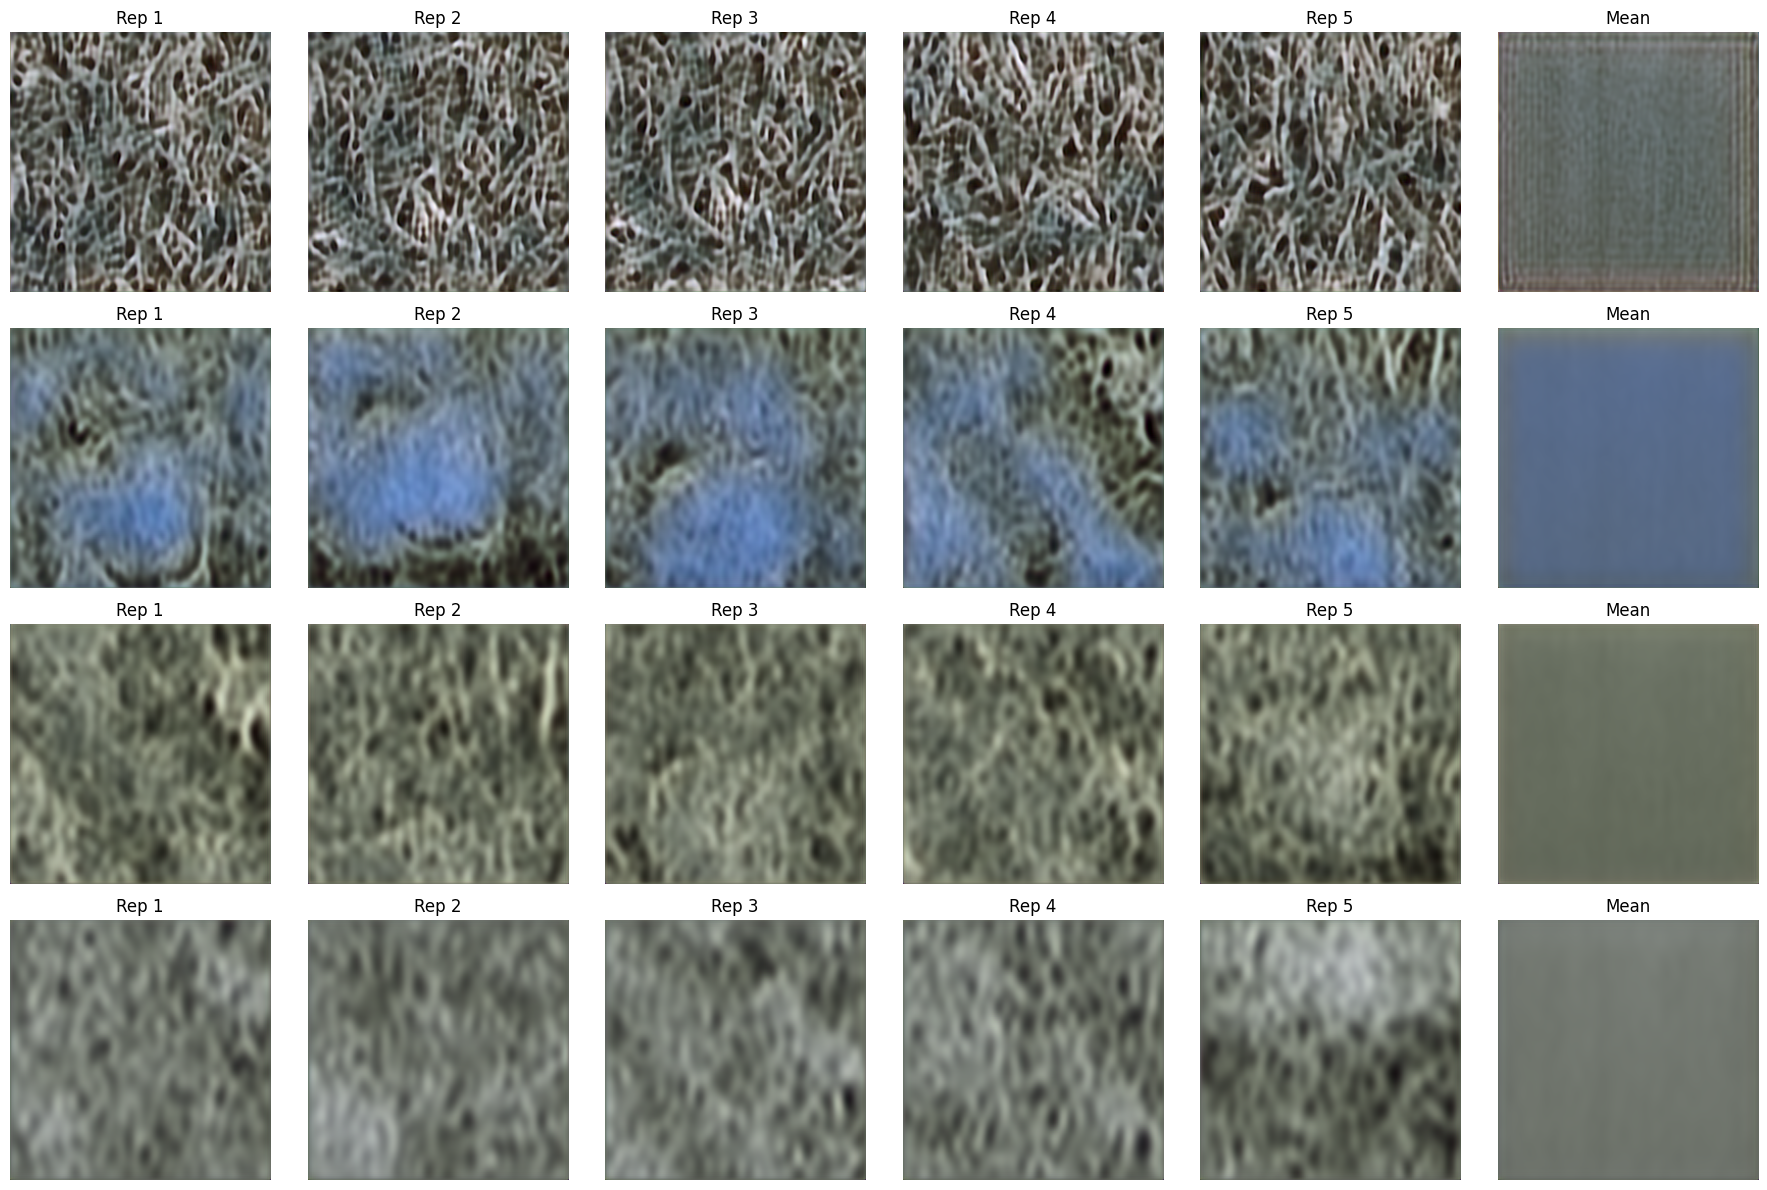

In [41]:
analyze_and_plot_all_models(models["init"], filtered_test_dataset, target_key='label', device='cuda', k=5)

In [ ]:
analyze_and_plot_all_models(models["mid"], filtered_test_dataset, target_key='label', device='cuda', k=5)

Processing model: kl_0_00
Processing model: kl_1_00
Processing model: kl_2_00
Processing model: kl_3_00


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.019792013..1.0033417].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.035389483..0.9639643].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.029016297..0.9771274].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.041755594..1.0410702].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.02604501..0.95383126].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0186043..1.0504694].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [

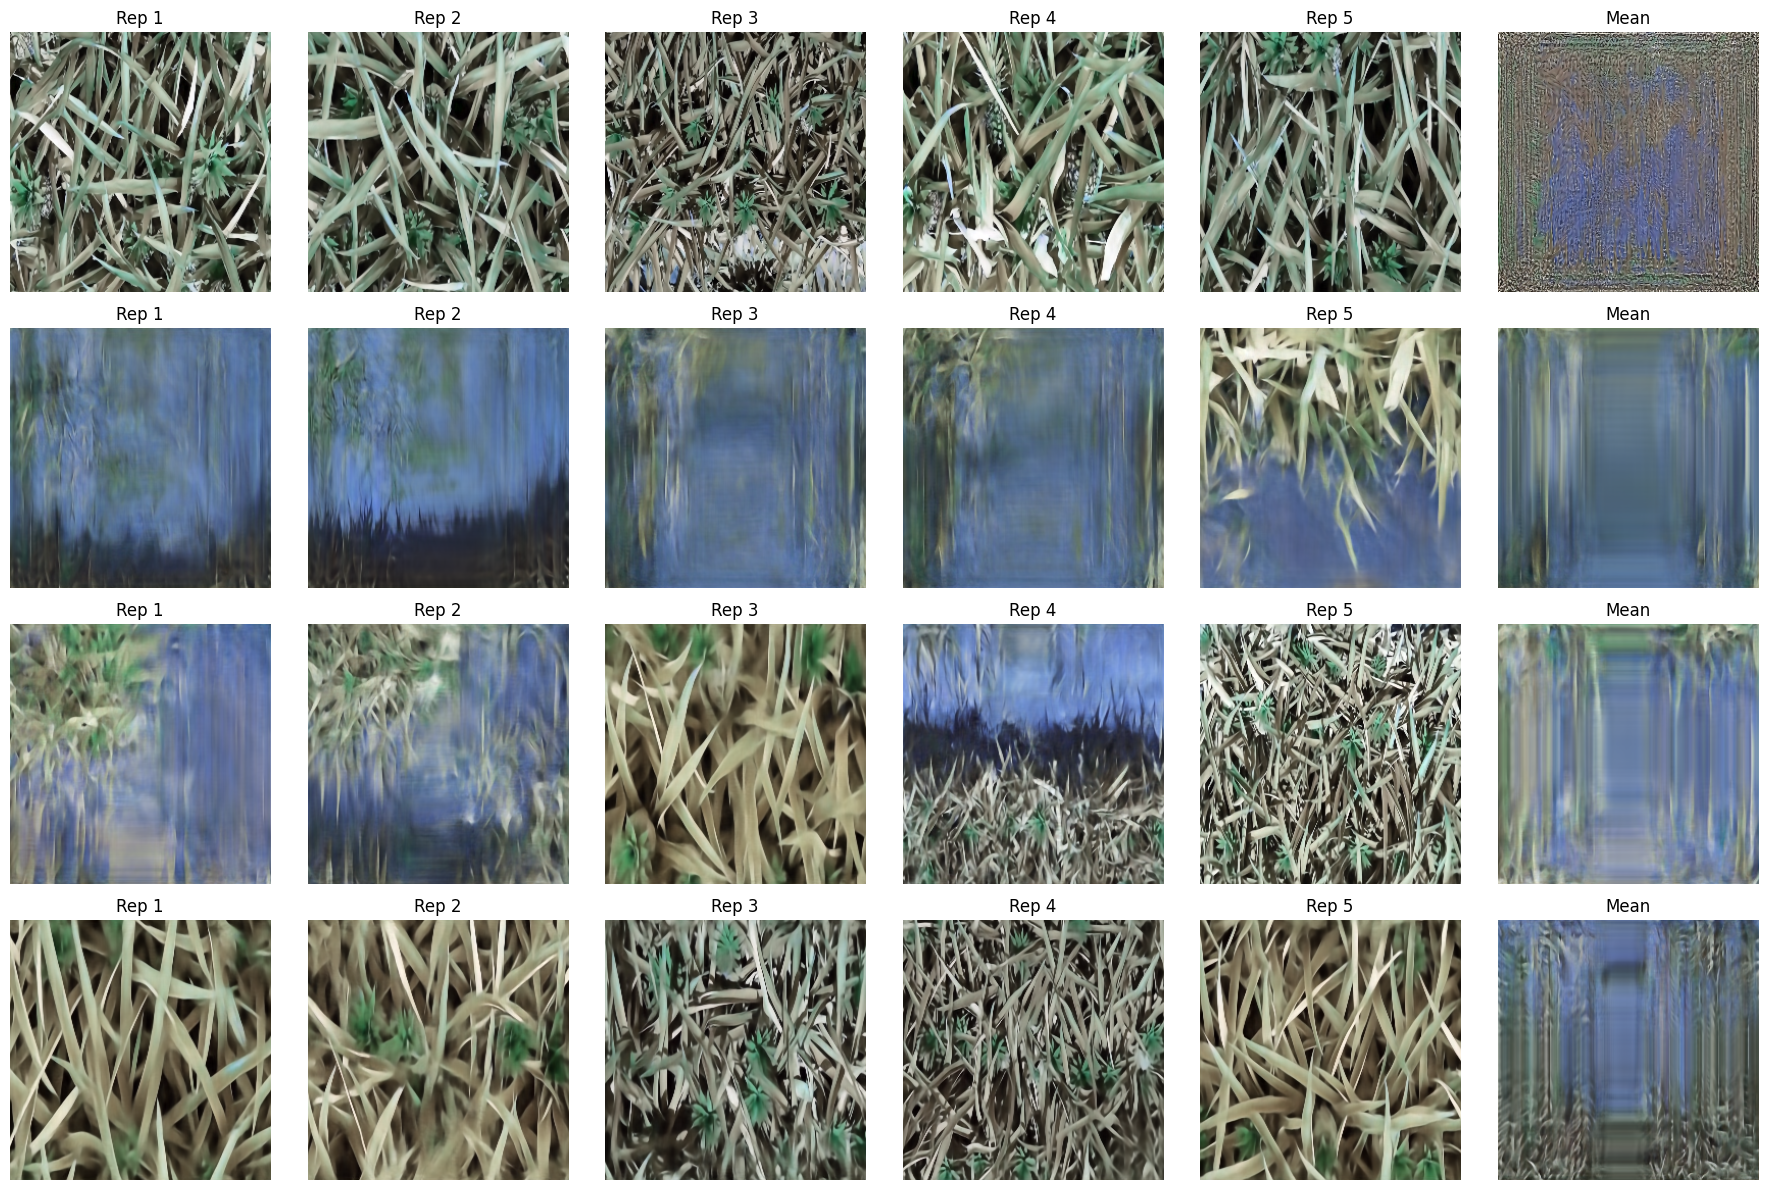

In [17]:
analyze_and_plot_all_models(models["last"], filtered_test_dataset, target_key='label', device='cuda', k=5)

In [13]:
model = models["init"]['kl_0_00']

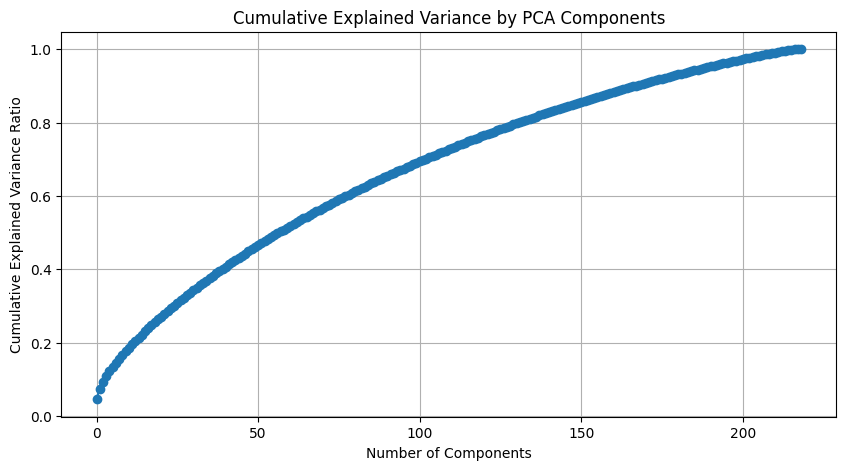

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.03829036..1.0177941].


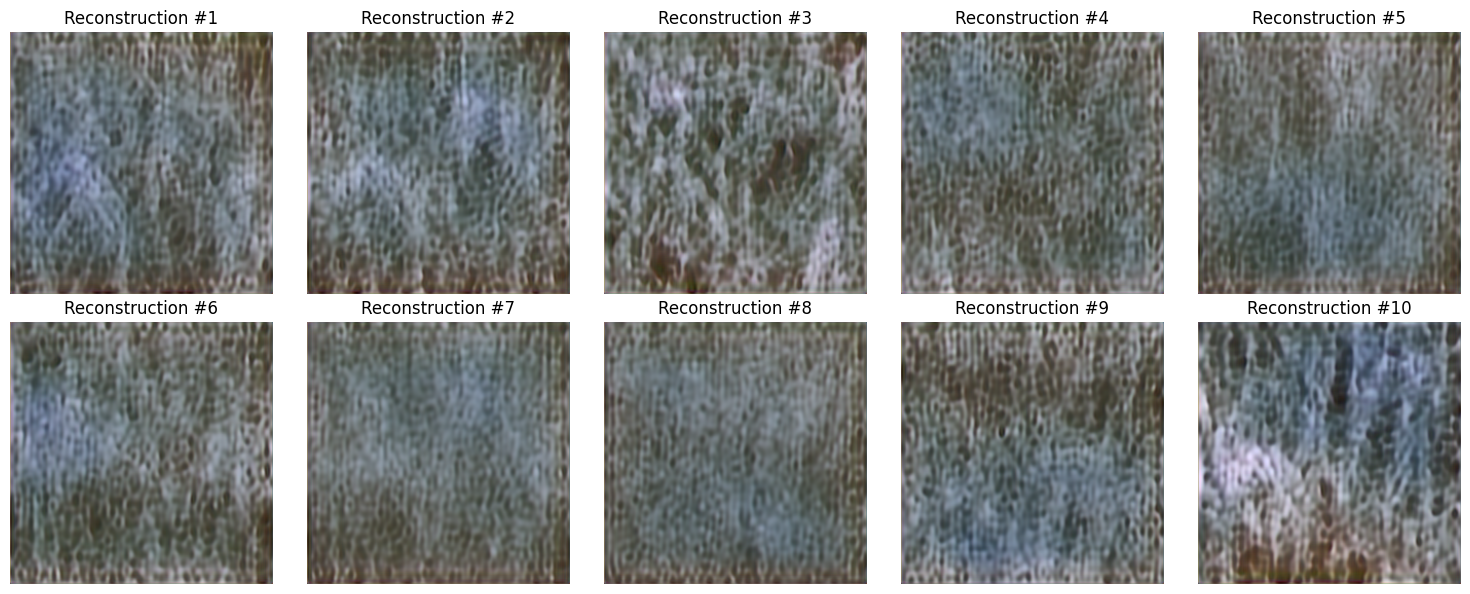

In [15]:
import torch
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def extract_latents_without_flatten(model, test_loader, target_key='label', device='cuda'):
    model.eval()
    model.to(device)

    all_latents = []
    all_targets = []

    with torch.no_grad():
        for batch in test_loader:
            input_tensor = batch['image'].to(device).unsqueeze(0)  # shape: (B=1,C,H,W)

            batch_size, _, height, width = input_tensor.shape
            # Create noise matching your model encoder input requirements
            noise = torch.randn((batch_size, 4, height // 8, width // 8), device=device)
            latent, mean, logvar = model.encoder(input_tensor, noise)  # latent shape (B, C, H, W)

            # Remove batch dim and move to cpu numpy
            all_latents.append(latent.squeeze(0).cpu().numpy())
            all_targets.append(batch[target_key])

    all_latents = np.stack(all_latents)  # shape: (num_samples, C, H, W)
    targets_cleaned = np.array(all_targets)

    return all_latents, targets_cleaned


# Example usage to extract latents from your dataset & model
data_cleaned, label_cleaned = extract_latents_without_flatten(model, filtered_test_dataset, target_key="label", device='cuda')

# Flatten latents for PCA: (N, C*H*W)
N, C, H, W = data_cleaned.shape
latents_flat = data_cleaned.reshape(N, -1)

# PCA
pca = PCA()
latents_pca = pca.fit_transform(latents_flat)

# Explained variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = explained_variance_ratio.cumsum()

# Plot cumulative explained variance
plt.figure(figsize=(10, 5))
plt.plot(cumulative_variance, marker='o')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.show()

# Optional: reconstruct from top-k components and decode with VAE decoder
k = 10  # number of PCA components to keep
pca_k = PCA(n_components=k)
latents_k = pca_k.fit_transform(latents_flat)
reconstructed_flat = pca_k.inverse_transform(latents_k)

# Reshape back to original latent shape (N, C, H, W)
reconstructed_latents = torch.tensor(reconstructed_flat).view(N, C, H, W).to('cuda')

# Select first 10 reconstructed latents
reconstructed_latents_10 = reconstructed_latents[:10]

model.eval()
model.decoder.to('cuda')

with torch.no_grad():
    # Decode to images
    reconstructions_10 = model.decoder(reconstructed_latents_10).cpu()  # shape: (10, C, H, W)

# Assuming images are single-channel or 3-channel and normalized between 0-1
# If grayscale, squeeze channel dimension for plotting
def plot_images(images, ncols=5, figsize=(15, 6), title_prefix='Reconstruction'):
    n = len(images)
    nrows = (n + ncols - 1) // ncols
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        plt.subplot(nrows, ncols, i + 1)
        if img.shape[0] == 1:  # grayscale image
            plt.imshow(img.squeeze(0), cmap='gray')
        else:  # RGB
            # transpose from (C, H, W) to (H, W, C)
            plt.imshow(img.permute(1, 2, 0))
        plt.axis('off')
        plt.title(f'{title_prefix} #{i+1}')
    plt.tight_layout()
    plt.show()

plot_images(reconstructions_10)


Top 10 most informative latent dimensions (PCA components):
Component 0: explained variance ratio = 0.0459
Component 1: explained variance ratio = 0.0292
Component 2: explained variance ratio = 0.0186
Component 3: explained variance ratio = 0.0148
Component 4: explained variance ratio = 0.0140
Component 5: explained variance ratio = 0.0120
Component 6: explained variance ratio = 0.0113
Component 7: explained variance ratio = 0.0104
Component 8: explained variance ratio = 0.0103
Component 9: explained variance ratio = 0.0098


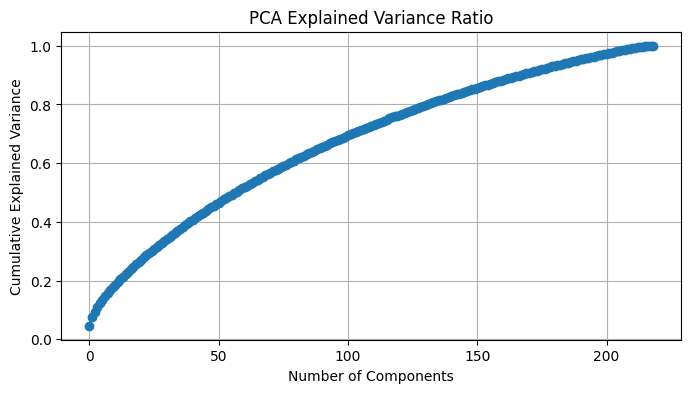

In [16]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def identify_informative_latent_dims(latents, top_k=5):
    """
    latents: numpy array of shape (N, C, H, W)
    top_k: how many top components to print
    
    Returns:
    pca: fitted PCA object
    top_components: list of tuples (component_index, explained_variance_ratio)
    """
    N, C, H, W = latents.shape
    latents_flat = latents.reshape(N, -1)  # Flatten to (N, C*H*W)

    pca = PCA()
    pca.fit(latents_flat)

    # Explained variance ratio per component
    evr = pca.explained_variance_ratio_

    # Get top_k components by explained variance ratio
    top_indices = np.argsort(evr)[::-1][:top_k]
    top_components = [(i, evr[i]) for i in top_indices]

    print(f"Top {top_k} most informative latent dimensions (PCA components):")
    for idx, var_ratio in top_components:
        print(f"Component {idx}: explained variance ratio = {var_ratio:.4f}")

    # Plot explained variance ratio (optional)
    plt.figure(figsize=(8,4))
    plt.plot(np.cumsum(evr), marker='o')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('PCA Explained Variance Ratio')
    plt.grid(True)
    plt.show()

    return pca, top_components

# Example usage:
# latents_np = your_latents_as_numpy_array_of_shape_(N, C, H, W)
pca_model, top_latent_dims = identify_informative_latent_dims(data_cleaned, top_k=10)
